# SAMPL5 results

In [1]:
import io
import warnings
from typing import Union

import cairosvg
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.colors import to_rgb
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

warnings.filterwarnings("ignore")

In [2]:
# Load the SAMPL5 dataset with SMILES
df_sampl5 = pd.read_csv("../../datasets/SAMPL5/SAMPL5_selected.csv")

SMILES_MAP = dict(zip(df_sampl5["Molecule ID"], df_sampl5["SMILES"]))
MOLECULES = df_sampl5["Molecule ID"].tolist()

print("Loaded SMILES for molecules:")
for mol_id, smiles in SMILES_MAP.items():
    print(f"{mol_id}: {smiles}")

Loaded SMILES for molecules:
SAMPL5_019: Cc1ccc(cc1)Nc2ccnc(n2)Nc3ccc(cc3)C
SAMPL5_020: CCCC(=O)Nc1nc2ccc(cc2s1)C(C)C
SAMPL5_021: Cc1nn2cc(nc2s1)c3cccc(c3)OC
SAMPL5_046: CSc1ccc(cc1)CC(=O)Nc2c3ccsc3ncn2
SAMPL5_058: c1ccc(cc1)n2c(=O)c3ccccc3cn2
SAMPL5_068: c1ccc(cc1)c2c(nnc(n2)c3ccccn3)c4ccccc4
SAMPL5_071: CCOc1cc(c(cc1N2CCOCC2)OCC)N
SAMPL5_080: Cn1cnc2c1c(=O)n(c(=O)n2C)C
SAMPL5_090: Cc1cc2c(cc1C)nc(c(n2)c3ccccn3)c4ccccn4


In [3]:
# Adapted from https://github.com/OpenFreeEnergy/cinnabar/blob/26eecb75bdbb5d7baf8798615feed16effe62abb/cinnabar/stats.py#L8
def bootstrap_statistic(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dy_true: Union[np.ndarray, None] = None,
    dy_pred: Union[np.ndarray, None] = None,
    ci: float = 0.95,
    statistic: str = "RMSE",
    nbootstrap: int = 10000,
    plot_type: str = "dG",
    include_true_uncertainty: bool = False,
    include_pred_uncertainty: bool = False,
) -> dict:
    """
    Compute mean and confidence intervals of specified statistic.

    Parameters
    ----------
    y_true : ndarray with shape (N,)
        True values
    y_pred : ndarray with shape (N,)
        Predicted values
    dy_true : ndarray with shape (N,) or None
        Errors of true values. If None, the values are assumed to have no errors
    dy_pred : ndarray with shape (N,) or None
        Errors of predicted values. If None, the values are assumed to have no errors
    ci : float, optional, default=0.95
        Interval for confidence interval (CI)
    statistic : str
        Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','KTAU','RAE']
    nbootstrap : int, optional, default=1000
        Number of bootstrap samples
    plot_type : str, optional, default='dG'
        'dG' or 'ddG'
    include_true_uncertainty : bool, default False
        whether to account for the uncertainty in y_true when bootstrapping
    include_pred_uncertainty : bool, default False
        whether to account for the uncertainty in y_pred when bootstrapping

    Returns
    -------
    rmse_stats : dict of float
        'mean' : mean RMSE
        'stderr' : standard error
        'low' : low end of CI
        'high' : high end of CI
    """

    def compute_statistic(
        y_true_sample: np.ndarray, y_pred_sample: np.ndarray, statistic: str
    ):
        """Compute requested statistic.

        Parameters
        ----------
        y_true : ndarray with shape (N,)
            True values
        y_pred : ndarray with shape (N,)
            Predicted values
        statistic : str
            Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','RAE','KTAU']

        """

        def calc_RAE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            MAE = sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
            mean = np.mean(y_true_sample)
            MAD = np.sum([np.abs(mean - i) for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            return MAE / MAD

        def calc_RRMSE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            rmse = np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
            mean_exp = np.mean(y_true_sample)
            mds = np.sum([(mean_exp - i) ** 2 for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            rrmse = np.sqrt(rmse**2 / mds)
            return rrmse

        if statistic == "RMSE":
            return np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
        elif statistic == "MUE":
            return sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
        elif statistic == "MSE":
            # mean signed error
            return np.mean(y_pred_sample - y_true_sample)
        elif statistic == "R2":
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
                y_true_sample, y_pred_sample
            )
            return r_value**2
        elif statistic == "rho":
            return scipy.stats.pearsonr(y_true_sample, y_pred_sample)[0]
        elif statistic == "RAE":
            return calc_RAE(y_true_sample, y_pred_sample)
        elif statistic == "KTAU":
            return scipy.stats.kendalltau(y_true_sample, y_pred_sample)[0]
        else:
            raise Exception("unknown statistic '{}'".format(statistic))

    # not used?
    def unique_differences(x):
        """Compute all unique differences"""
        N = len(x)
        return np.array([(x[i] - x[j]) for i in range(N) for j in range(N) if (i != j)])

    if dy_true is None:
        dy_true = np.zeros_like(y_true)
    if dy_pred is None:
        dy_pred = np.zeros_like(y_pred)
    assert len(y_true) == len(y_pred)
    assert len(y_true) == len(dy_true)
    assert len(y_true) == len(dy_pred)
    sample_size = len(y_true)
    s_n = np.zeros(
        [nbootstrap], np.float64
    )  # s_n[n] is the statistic computed for bootstrap sample n
    for replicate in range(nbootstrap):
        y_true_sample = np.zeros_like(y_true)
        y_pred_sample = np.zeros_like(y_pred)
        for i, j in enumerate(
            np.random.choice(np.arange(sample_size), size=[sample_size], replace=True)
        ):
            stddev_true = np.fabs(dy_true[j]) if include_true_uncertainty else 0
            stddev_pred = np.fabs(dy_pred[j]) if include_pred_uncertainty else 0
            y_true_sample[i] = np.random.normal(
                loc=y_true[j], scale=stddev_true, size=1
            )
            y_pred_sample[i] = np.random.normal(
                loc=y_pred[j], scale=stddev_pred, size=1
            )
        s_n[replicate] = compute_statistic(y_true_sample, y_pred_sample, statistic)

    rmse_stats = dict()
    rmse_stats["mle"] = compute_statistic(y_true, y_pred, statistic)
    rmse_stats["stderr"] = np.std(s_n)
    rmse_stats["mean"] = np.mean(s_n)
    # TODO: Is there a canned method to do this?
    s_n = np.sort(s_n)
    low_frac = (1.0 - ci) / 2.0
    high_frac = 1.0 - low_frac
    rmse_stats["low"] = s_n[int(np.floor(nbootstrap * low_frac))]
    rmse_stats["high"] = s_n[int(np.ceil(nbootstrap * high_frac))]

    return rmse_stats

## Load data

In [4]:
# Load data from Excel file
excel_file_path = "final_paper_LJ.xlsx"

df_wat = pd.read_excel(excel_file_path, sheet_name="SAMPL5-WAT-EE", header=1)
df_chx = pd.read_excel(excel_file_path, sheet_name="SAMPL5-CHX-EE", header=1)
df_wat_me = pd.read_excel(excel_file_path, sheet_name="SAMPL5-WAT-ME", header=1)
df_chx_me = pd.read_excel(excel_file_path, sheet_name="SAMPL5-CHX-ME", header=1)

# Define column groups
MACE_OFF23_SMALL_COLS = [
    "MACE-OFF23(S)-Rep1",
    "MACE-OFF23(S)-Rep2",
    "MACE-OFF23(S)-Rep3",
]
MACE_OFF24_MEDIUM_COLS = [
    "MACE-OFF24(M)-Rep1",
    "MACE-OFF24(M)-Rep2",
    "MACE-OFF24(M)-Rep3",
]
FENNIX_BIO1_SMALL_COLS = [
    "FeNNix-Bio1(S)-Rep1",
    "FeNNix-Bio1(S)-Rep2",
    "FeNNix-Bio1(S)-Rep3",
]
FENNIX_BIO1_MEDIUM_COLS = [
    "FeNNix-Bio1(M)-Rep1",
    "FeNNix-Bio1(M)-Rep2",
    "FeNNix-Bio1(M)-Rep3",
]
MM_XDM_COLS = ["MM-XDM-Rep1", "MM-XDM-Rep2", "MM-XDM-Rep3"]
MM_COLS = ["MM-Rep1", "MM-Rep2", "MM-Rep3"]

EXP_LOG_P_MEAN = [1.4, 1.7, 1.2, 0.2, 0.8, 1.4, 0.0, -2.2, 0.7]
EXP_LOG_P_STD = [0.70, 0.3, 0.3, 0.3, 0.6, 0.3, 0.4, 0.3, 0.2]

# Calculate means
MM_WAT_MEAN = df_wat[MM_COLS].mean(axis=1)
MM_CHX_MEAN = df_chx[MM_COLS].mean(axis=1)
MACE_OFF23_SMALL_WAT_MEAN = df_wat[MACE_OFF23_SMALL_COLS].mean(axis=1)
MACE_OFF23_SMALL_CHX_MEAN = df_chx[MACE_OFF23_SMALL_COLS].mean(axis=1)
MACE_OFF24_MEDIUM_WAT_MEAN = df_wat[MACE_OFF24_MEDIUM_COLS].mean(axis=1)
MACE_OFF24_MEDIUM_CHX_MEAN = df_chx[MACE_OFF24_MEDIUM_COLS].mean(axis=1)
FENNIX_BIO1_SMALL_WAT_MEAN = df_wat[FENNIX_BIO1_SMALL_COLS].mean(axis=1)
FENNIX_BIO1_SMALL_CHX_MEAN = df_chx[FENNIX_BIO1_SMALL_COLS].mean(axis=1)
FENNIX_BIO1_MEDIUM_WAT_MEAN = df_wat[FENNIX_BIO1_MEDIUM_COLS].mean(axis=1)
FENNIX_BIO1_MEDIUM_CHX_MEAN = df_chx[FENNIX_BIO1_MEDIUM_COLS].mean(axis=1)
MM_XDM_WAT_MEAN = df_wat[MM_XDM_COLS].mean(axis=1)
MM_XDM_CHX_MEAN = df_chx[MM_XDM_COLS].mean(axis=1)

# Mechanical embeddings
MACE_OFF23_SMALL_WAT_ME_MEAN = df_wat_me[MACE_OFF23_SMALL_COLS].mean(axis=1)
MACE_OFF23_SMALL_CHX_ME_MEAN = df_chx_me[MACE_OFF23_SMALL_COLS].mean(axis=1)
MACE_OFF24_MEDIUM_WAT_ME_MEAN = df_wat_me[MACE_OFF24_MEDIUM_COLS].mean(axis=1)
MACE_OFF24_MEDIUM_CHX_ME_MEAN = df_chx_me[MACE_OFF24_MEDIUM_COLS].mean(axis=1)
FENNIX_BIO1_SMALL_WAT_ME_MEAN = df_wat_me[FENNIX_BIO1_SMALL_COLS].mean(axis=1)
FENNIX_BIO1_SMALL_CHX_ME_MEAN = df_chx_me[FENNIX_BIO1_SMALL_COLS].mean(axis=1)
FENNIX_BIO1_MEDIUM_WAT_ME_MEAN = df_wat_me[FENNIX_BIO1_MEDIUM_COLS].mean(axis=1)
FENNIX_BIO1_MEDIUM_CHX_ME_MEAN = df_chx_me[FENNIX_BIO1_MEDIUM_COLS].mean(axis=1)

# Calculate logP constant
logP_const = 1 / (2.303 * 0.0019872041 * 298.15)

# Calculate logP values
log_MM_MEAN = (MM_WAT_MEAN - MM_CHX_MEAN) * logP_const
logP_MACE_OFF23_SMALL_MEAN = (
    (MM_WAT_MEAN + MACE_OFF23_SMALL_WAT_MEAN)
    - (MM_CHX_MEAN + MACE_OFF23_SMALL_CHX_MEAN)
) * logP_const
logP_MACE_OFF24_MEDIUM_MEAN = (
    (MM_WAT_MEAN + MACE_OFF24_MEDIUM_WAT_MEAN)
    - (MM_CHX_MEAN + MACE_OFF24_MEDIUM_CHX_MEAN)
) * logP_const
logP_FENNIX_BIO1_SMALL_MEAN = (
    (MM_WAT_MEAN + FENNIX_BIO1_SMALL_WAT_MEAN)
    - (MM_CHX_MEAN + FENNIX_BIO1_SMALL_CHX_MEAN)
) * logP_const
logP_FENNIX_BIO1_MEDIUM_MEAN = (
    (MM_WAT_MEAN + FENNIX_BIO1_MEDIUM_WAT_MEAN)
    - (MM_CHX_MEAN + FENNIX_BIO1_MEDIUM_CHX_MEAN)
) * logP_const
logP_MM_XDM_MEAN = (
    (MM_WAT_MEAN + MM_XDM_WAT_MEAN) - (MM_CHX_MEAN + MM_XDM_CHX_MEAN)
) * logP_const

# Mechanical embeddings
logP_MACE_OFF23_SMALL_ME_MEAN = (
    (MM_WAT_MEAN + MACE_OFF23_SMALL_WAT_ME_MEAN)
    - (MM_CHX_MEAN + MACE_OFF23_SMALL_CHX_ME_MEAN)
) * logP_const
logP_MACE_OFF24_MEDIUM_ME_MEAN = (
    (MM_WAT_MEAN + MACE_OFF24_MEDIUM_WAT_ME_MEAN)
    - (MM_CHX_MEAN + MACE_OFF24_MEDIUM_CHX_ME_MEAN)
) * logP_const
logP_FENNIX_BIO1_SMALL_ME_MEAN = (
    (MM_WAT_MEAN + FENNIX_BIO1_SMALL_WAT_ME_MEAN)
    - (MM_CHX_MEAN + FENNIX_BIO1_SMALL_CHX_ME_MEAN)
) * logP_const
logP_FENNIX_BIO1_MEDIUM_ME_MEAN = (
    (MM_WAT_MEAN + FENNIX_BIO1_MEDIUM_WAT_ME_MEAN)
    - (MM_CHX_MEAN + FENNIX_BIO1_MEDIUM_CHX_ME_MEAN)
) * logP_const

# Calculate uncertainties
t_student_coeff = 1
logP_MM_ERROR = (
    t_student_coeff
    * np.sqrt(df_wat[MM_COLS].std(axis=1) ** 2 + df_chx[MM_COLS].std(axis=1) ** 2)
    / np.sqrt(3)
)
logP_MM_XDM_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat[MM_XDM_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx[MM_XDM_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_MACE_OFF23_SMALL_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat[MACE_OFF23_SMALL_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx[MACE_OFF23_SMALL_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_MACE_OFF24_MEDIUM_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat[MACE_OFF24_MEDIUM_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx[MACE_OFF24_MEDIUM_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_FENNIX_BIO1_SMALL_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat[FENNIX_BIO1_SMALL_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx[FENNIX_BIO1_SMALL_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_FENNIX_BIO1_MEDIUM_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat[FENNIX_BIO1_MEDIUM_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx[FENNIX_BIO1_MEDIUM_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_MACE_OFF23_SMALL_ME_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat_me[MACE_OFF23_SMALL_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx_me[MACE_OFF23_SMALL_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_MACE_OFF24_MEDIUM_ME_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat_me[MACE_OFF24_MEDIUM_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx_me[MACE_OFF24_MEDIUM_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_FENNIX_BIO1_SMALL_ME_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat_me[FENNIX_BIO1_SMALL_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx_me[FENNIX_BIO1_SMALL_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)
logP_FENNIX_BIO1_MEDIUM_ME_ERROR = (
    t_student_coeff
    * np.sqrt(
        df_wat[MM_COLS].std(axis=1) ** 2
        + df_wat_me[FENNIX_BIO1_MEDIUM_COLS].std(axis=1) ** 2
        + df_chx[MM_COLS].std(axis=1) ** 2
        + df_chx_me[FENNIX_BIO1_MEDIUM_COLS].std(axis=1) ** 2
    )
    / np.sqrt(3)
)

# Create dataframes
df_data_mean = pd.DataFrame(
    {
        "logP EXP": EXP_LOG_P_MEAN,
        "logP OpenFF": log_MM_MEAN,
        "logP MM-XDM": logP_MM_XDM_MEAN,
        "logP MACE-OFF23(S)": logP_MACE_OFF23_SMALL_MEAN,
        "logP MACE-OFF23(S) ME": logP_MACE_OFF23_SMALL_ME_MEAN,
        "logP MACE-OFF24(M)": logP_MACE_OFF24_MEDIUM_MEAN,
        "logP MACE-OFF24(M) ME": logP_MACE_OFF24_MEDIUM_ME_MEAN,
        "logP FeNNix-Bio1(S)": logP_FENNIX_BIO1_SMALL_MEAN,
        "logP FeNNix-Bio1(S) ME": logP_FENNIX_BIO1_SMALL_ME_MEAN,
        "logP FeNNix-Bio1(M)": logP_FENNIX_BIO1_MEDIUM_MEAN,
        "logP FeNNix-Bio1(M) ME": logP_FENNIX_BIO1_MEDIUM_ME_MEAN,
    }
)

df_data_error = pd.DataFrame(
    {
        "logP EXP": EXP_LOG_P_STD,
        "logP OpenFF": logP_MM_ERROR,
        "logP MM-XDM": logP_MM_XDM_ERROR,
        "logP MACE-OFF23(S)": logP_MACE_OFF23_SMALL_ERROR,
        "logP MACE-OFF23(S) ME": logP_MACE_OFF23_SMALL_ME_ERROR,
        "logP MACE-OFF24(M)": logP_MACE_OFF24_MEDIUM_ERROR,
        "logP MACE-OFF24(M) ME": logP_MACE_OFF24_MEDIUM_ME_ERROR,
        "logP FeNNix-Bio1(S)": logP_FENNIX_BIO1_SMALL_ERROR,
        "logP FeNNix-Bio1(S) ME": logP_FENNIX_BIO1_SMALL_ME_ERROR,
        "logP FeNNix-Bio1(M)": logP_FENNIX_BIO1_MEDIUM_ERROR,
        "logP FeNNix-Bio1(M) ME": logP_FENNIX_BIO1_MEDIUM_ME_ERROR,
    }
)

# Get MOLECULES list from Excel file (to match data order)
MOLECULES_ALL = df_wat["Molecule"].tolist()

# Get experimental data
exp = df_data_mean["logP EXP"]
n_mol = len(MOLECULES)

# Model display names
model_cols = [c for c in df_data_mean.columns if c != "logP EXP"]
model_display = {
    "logP OpenFF": "OpenFF",
    "logP MACE-OFF23(S)": "MACE-OFF23(S)/EMLE/XDM-EXP",
    "logP MACE-OFF23(S) ME": "MACE-OFF23(S)",
    "logP MACE-OFF24(M)": "MACE-OFF24(M)/EMLE/XDM-EXP",
    "logP MACE-OFF24(M) ME": "MACE-OFF24(M)",
    "logP FeNNix-Bio1(S)": "FeNNix-Bio1(S)/EMLE/XDM-EXP",
    "logP FeNNix-Bio1(S) ME": "FeNNix-Bio1(S)",
    "logP FeNNix-Bio1(M)": "FeNNix-Bio1(M)/EMLE/XDM-EXP",
    "logP FeNNix-Bio1(M) ME": "FeNNix-Bio1(M)",
    "logP MM-XDM": "OpenFF/EMLE/XDM-EXP",
}

# Create bar plot dataframe
rows = []
for col in model_cols:
    signed_error = df_data_mean[col] - exp
    error = df_data_error[col]
    for mol, se, err in zip(MOLECULES, signed_error, error):
        rows.append(
            {"Molecule": mol, "Model": model_display[col], "Mean": se, "Error": err}
        )

df_bar = pd.DataFrame(rows)
df_bar.head(15)

,Molecule,Model,Mean,Error
0,SAMPL5_019,OpenFF,1.239125,0.042031
1,SAMPL5_020,OpenFF,-0.458676,0.028030
2,SAMPL5_021,OpenFF,1.859428,0.036459
3,SAMPL5_046,OpenFF,2.588649,0.022748
4,SAMPL5_058,OpenFF,1.284475,0.039048
5,SAMPL5_068,OpenFF,2.536341,0.040821
6,SAMPL5_071,OpenFF,1.552888,0.032894
7,SAMPL5_080,OpenFF,-1.219576,0.030996
8,SAMPL5_090,OpenFF,3.886072,0.034944
9,SAMPL5_019,OpenFF/EMLE/XDM-EXP,1.474882,0.098982


## Signed errors

In [5]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by blending with white.
    amount=0 -> original color, amount=1 -> white
    """
    c = to_rgb(color)
    white = (1, 1, 1)
    new_color = tuple((1 - amount) * ci + amount * wi for ci, wi in zip(c, white))
    return new_color

In [6]:
cb_colors = sns.color_palette("colorblind")

palette = {
    "OpenFF/EMLE/XDM-EXP": cb_colors[7],
    "OpenFF": lighten_color(cb_colors[7], 0.5),
    "MACE-OFF23(S)/EMLE/XDM-EXP": cb_colors[1],
    "MACE-OFF23(S)": lighten_color(cb_colors[1], 0.5),
    "MACE-OFF24(M)/EMLE/XDM-EXP": cb_colors[2],
    "MACE-OFF24(M)": lighten_color(cb_colors[2], 0.5),
    "FeNNix-Bio1(S)/EMLE/XDM-EXP": cb_colors[0],
    "FeNNix-Bio1(S)": lighten_color(cb_colors[0], 0.5),
    "FeNNix-Bio1(M)/EMLE/XDM-EXP": cb_colors[3],
    "FeNNix-Bio1(M)": lighten_color(cb_colors[3], 0.5),
}

model_order = [
    "OpenFF/EMLE/XDM-EXP",
    "MACE-OFF23(S)/EMLE/XDM-EXP",
    "MACE-OFF24(M)/EMLE/XDM-EXP",
    "FeNNix-Bio1(S)/EMLE/XDM-EXP",
    "FeNNix-Bio1(M)/EMLE/XDM-EXP",
    "OpenFF",
    "MACE-OFF23(S)",
    "MACE-OFF24(M)",
    "FeNNix-Bio1(S)",
    "FeNNix-Bio1(M)",
]

display_to_col = {v: k for k, v in model_display.items()}

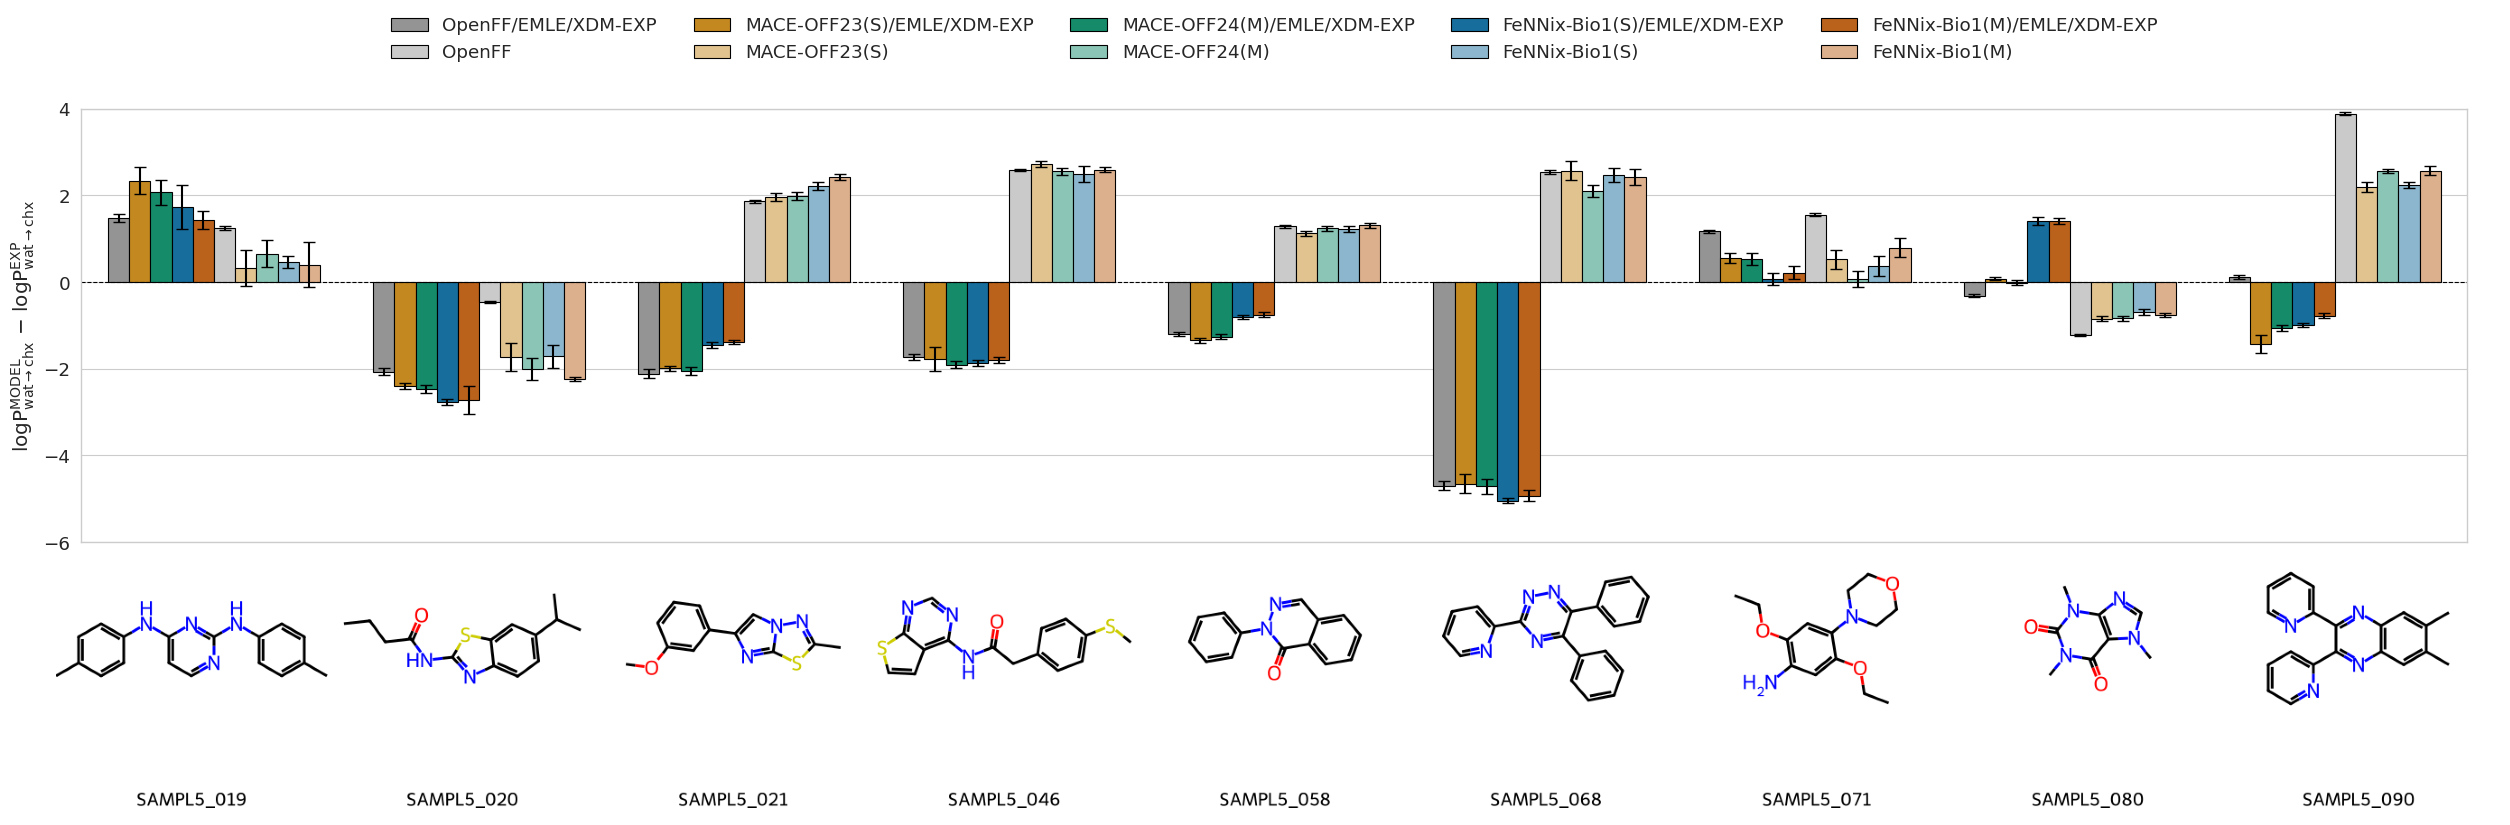

In [7]:
sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, ax = plt.subplots(figsize=(27.5, 8))

sns.barplot(
    data=df_bar,
    x="Molecule",
    y="Mean",
    hue="Model",
    order=MOLECULES,
    hue_order=model_order,
    edgecolor="black",
    palette=palette,
    ax=ax,
)

# Add error bars
bar_patches = [p for p in ax.patches if p.get_width() > 0]
for idx, patch in enumerate(bar_patches):
    mol_idx = idx % n_mol
    model_idx = idx // n_mol
    model_name = model_order[model_idx]
    col = display_to_col[model_name]
    err = df_data_error[col].iloc[mol_idx]
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.errorbar(
        x, height, yerr=err, ecolor="black", capsize=4, fmt="none", linewidth=1.5
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Set labels and limits
ax.set_ylabel(
    r"logP$^{\rm MODEL}_{\rm wat \rightarrow chx}$ $-$ logP$^{\rm EXP}_{\rm wat \rightarrow chx}$"
)
ax.set_xlabel("")
ax.set_ylim(-6, 4)
ax.set_xlim(-0.5, n_mol - 0.5)

# Remove x-tick labels and marks
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

# Add legend
handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))

emle_models = model_order[:5]
standalone_models = model_order[5:]
legend_order = []
for emle, standalone in zip(emle_models, standalone_models):
    legend_order.extend([emle, standalone])

ordered_handles = [label_to_handle[model] for model in legend_order]
ordered_labels = legend_order

ax.legend(
    ordered_handles,
    ordered_labels,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=5,
)

# Load SVG grid and convert to PNG
png_data = io.BytesIO()
cairosvg.svg2png(url="../../datasets/SAMPL5/molecules_grid_plot.svg", write_to=png_data)
png_data.seek(0)
img = mpimg.imread(png_data)

# Add image below plot
imagebox = OffsetImage(img, zoom=0.65)  # adjust zoom as needed
ab = AnnotationBbox(
    imagebox, (0.5, -0.30), xycoords="axes fraction", frameon=False, zorder=0
)
ax.add_artist(ab)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig(
    "logP_signed_errors_SAMPL5.pdf", bbox_inches="tight", dpi=600, transparent=True
)
plt.show()

## Statistical analysis

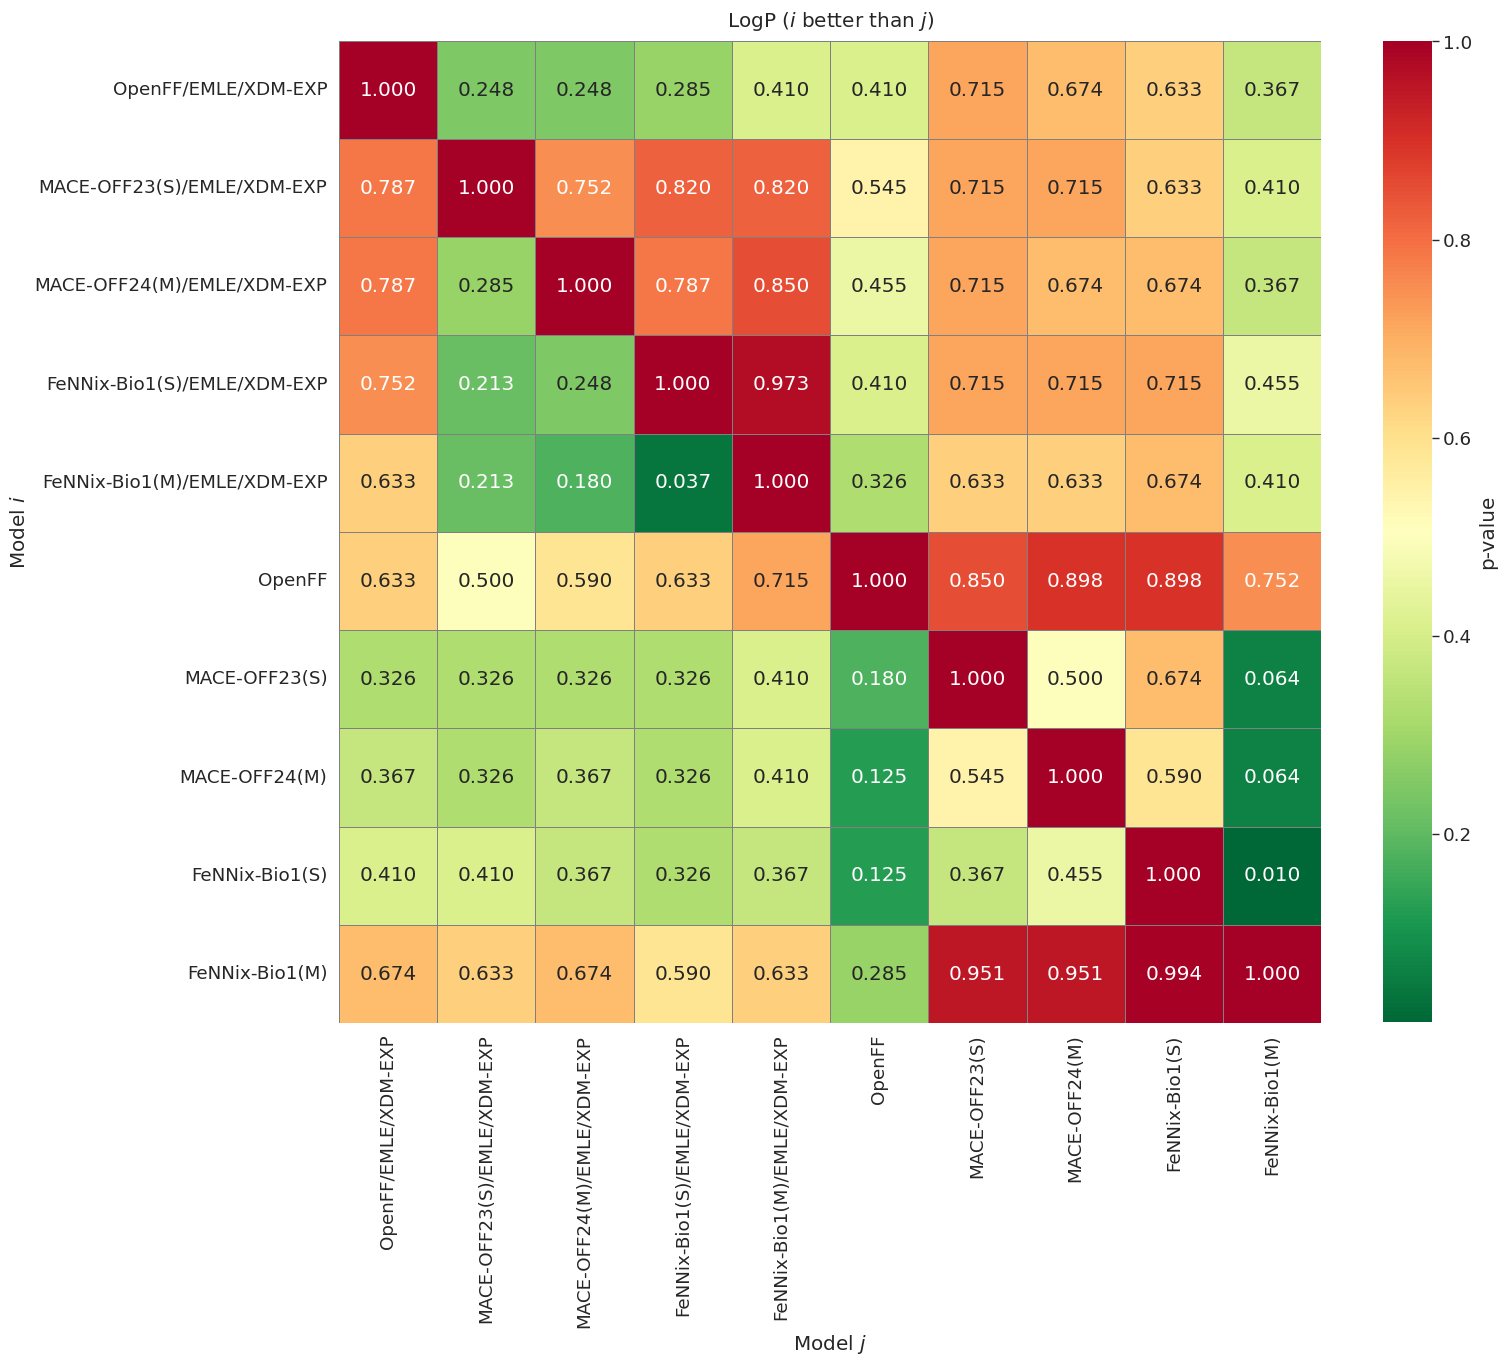

In [8]:
from scipy.stats import wilcoxon

exp_logP = df_data_mean["logP EXP"].to_numpy()

abs_error_MM = np.abs(df_data_mean["logP OpenFF"].to_numpy() - exp_logP)
abs_error_MACE_OFF23_S = np.abs(
    df_data_mean["logP MACE-OFF23(S)"].to_numpy() - exp_logP
)
abs_error_MACE_OFF24_M = np.abs(
    df_data_mean["logP MACE-OFF24(M)"].to_numpy() - exp_logP
)
abs_error_FENNIX_S = np.abs(df_data_mean["logP FeNNix-Bio1(S)"].to_numpy() - exp_logP)
abs_error_FENNIX_M = np.abs(df_data_mean["logP FeNNix-Bio1(M)"].to_numpy() - exp_logP)
abs_error_MM_XDM = np.abs(df_data_mean["logP MM-XDM"].to_numpy() - exp_logP)

# mechanical embeddings
abs_error_MACE_OFF23_S_ME = np.abs(
    df_data_mean["logP MACE-OFF23(S) ME"].to_numpy() - exp_logP
)
abs_error_MACE_OFF24_M_ME = np.abs(
    df_data_mean["logP MACE-OFF24(M) ME"].to_numpy() - exp_logP
)
abs_error_FENNIX_S_ME = np.abs(
    df_data_mean["logP FeNNix-Bio1(S) ME"].to_numpy() - exp_logP
)
abs_error_FENNIX_M_ME = np.abs(
    df_data_mean["logP FeNNix-Bio1(M) ME"].to_numpy() - exp_logP
)

names = [
    "OpenFF/EMLE/XDM-EXP",
    "MACE-OFF23(S)/EMLE/XDM-EXP",
    "MACE-OFF24(M)/EMLE/XDM-EXP",
    "FeNNix-Bio1(S)/EMLE/XDM-EXP",
    "FeNNix-Bio1(M)/EMLE/XDM-EXP",
    "OpenFF",
    "MACE-OFF23(S)",
    "MACE-OFF24(M)",
    "FeNNix-Bio1(S)",
    "FeNNix-Bio1(M)",
]
all_errors = [
    abs_error_MM_XDM,
    abs_error_MACE_OFF23_S,
    abs_error_MACE_OFF24_M,
    abs_error_FENNIX_S,
    abs_error_FENNIX_M,
    abs_error_MM,
    abs_error_MACE_OFF23_S_ME,
    abs_error_MACE_OFF24_M_ME,
    abs_error_FENNIX_S_ME,
    abs_error_FENNIX_M_ME,
]


def compute_wilcoxon_matrix(errors):
    n = len(errors)
    p_values = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                try:
                    _, p = wilcoxon(errors[i], errors[j], alternative="less")
                    p_values[i, j] = p
                except ValueError:
                    p_values[i, j] = np.nan
    return p_values


p_values = compute_wilcoxon_matrix(all_errors)

sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, ax = plt.subplots(1, 1, figsize=(16, 16))

sns.heatmap(
    p_values,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    xticklabels=names,
    yticklabels=names,
    cbar_kws={"label": "p-value", "shrink": 0.73},
    linewidths=0.5,
    linecolor="gray",
    square=True,
    ax=ax,
)
ax.set_xlabel("Model $j$")
ax.set_ylabel("Model $i$")
ax.set_title(r"LogP ($i$ better than $j$)", pad=10)

plt.tight_layout()
plt.savefig(
    "logP_wilcoxon_pvalues_SAMPL5.pdf", bbox_inches="tight", dpi=300, transparent=True
)
plt.show()


## Error analysis

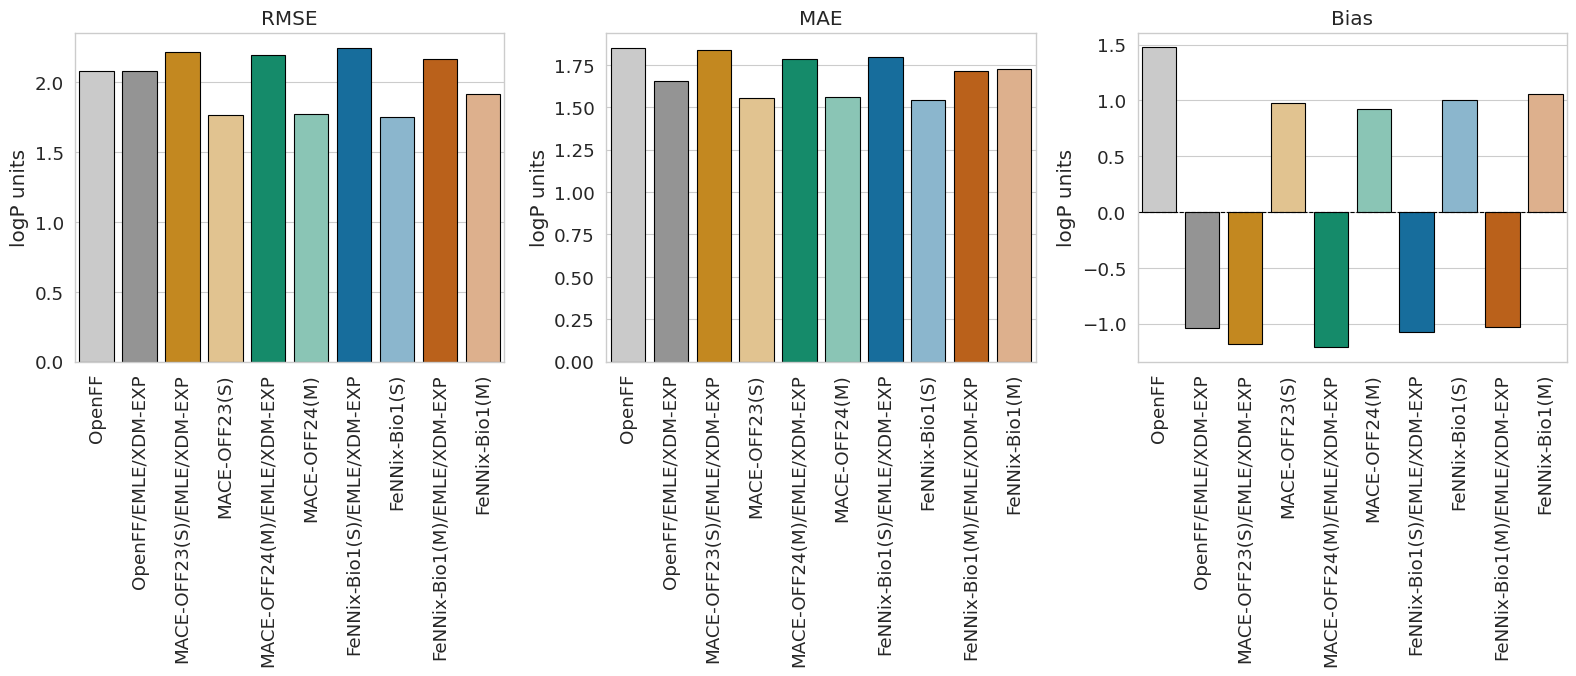

In [9]:
model_cols = [c for c in df_data_mean.columns if c != "logP EXP"]

exp = df_data_mean["logP EXP"].to_numpy()

metric_rows = []
for col in model_cols:
    pred = df_data_mean[col].to_numpy()
    valid = ~(np.isnan(exp) | np.isnan(pred))
    x_v, y_v = exp[valid], pred[valid]

    for metric in ["RMSE", "MUE", "MSE"]:
        s = bootstrap_statistic(x_v, y_v, statistic=metric)
        metric_rows.append(
            {
                "Model": model_display[col],
                "Metric": metric,
                "Value": s["mle"],
                "Low": s["low"],
                "High": s["high"],
            }
        )

df_metrics = pd.DataFrame(metric_rows)

metric_labels = {"RMSE": "RMSE", "MUE": "MAE", "MSE": "Bias"}
df_metrics["Metric"] = df_metrics["Metric"].map(metric_labels)


sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=False)

for ax, metric_label in zip(axes, ["RMSE", "MAE", "Bias"]):
    df_sub = df_metrics[df_metrics["Metric"] == metric_label].copy()
    bars = sns.barplot(
        data=df_sub,
        x="Model",
        y="Value",
        palette=palette,
        edgecolor="black",
        ax=ax,
    )
    """
    for bar, (_, row) in zip(ax.patches, df_sub.iterrows()):
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        yerr_low = height - row["Low"]
        yerr_high = row["High"] - height
        ax.errorbar(
            x, height,
            yerr=[[yerr_low], [yerr_high]],
            ecolor="black", capsize=5, fmt="none", linewidth=1.5,
        )
    """
    if metric_label == "Bias":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(metric_label)
    ax.set_xlabel("")
    ax.set_ylabel("logP units")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("logP_metrics_SAMPL5.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

In [10]:
exp_std = np.array(EXP_LOG_P_STD)

# EE/ME pairs
ee_me_pairs = [
    ("MACE-OFF23(S)", abs_error_MACE_OFF23_S, abs_error_MACE_OFF23_S_ME),
    ("MACE-OFF24(M)", abs_error_MACE_OFF24_M, abs_error_MACE_OFF24_M_ME),
    ("FeNNix-Bio1(S)", abs_error_FENNIX_S, abs_error_FENNIX_S_ME),
    ("FeNNix-Bio1(M)", abs_error_FENNIX_M, abs_error_FENNIX_M_ME),
    ("MM-XDM", abs_error_MM_XDM, abs_error_MM),
]

# Per molecule: EE outperforms or equals ME within sigma_exp  <=>  |err^EE| <= |err^ME| + sigma^EXP
results = {}
for label, err_ee, err_me in ee_me_pairs:
    results[label] = err_ee <= err_me + exp_std

df_ee_vs_me = pd.DataFrame(results, index=MOLECULES)
df_ee_vs_me.index.name = "Molecule"

n_models = len(ee_me_pairs)
n_true = df_ee_vs_me.sum(axis=1)

df_ee_vs_me["All EE >= ME"] = n_true == n_models
df_ee_vs_me["Mixed"] = (n_true > 0) & (n_true < n_models)
df_ee_vs_me["All ME > EE"] = n_true == 0
df_ee_vs_me


,MACE-OFF23(S),MACE-OFF24(M),FeNNix-Bio1(S),FeNNix-Bio1(M),MM-XDM,All EE >= ME,Mixed,All ME > EE
Molecule,,,,,,,,
SAMPL5_019,False,False,False,False,True,False,True,False
SAMPL5_020,False,False,False,False,False,False,False,True
SAMPL5_021,True,True,True,True,True,True,False,False
SAMPL5_046,True,True,True,True,True,True,False,False
SAMPL5_058,True,True,True,True,True,True,False,False
SAMPL5_068,False,False,False,False,False,False,False,True
SAMPL5_071,True,False,True,True,True,False,True,False
SAMPL5_080,True,True,False,False,True,False,True,False
SAMPL5_090,True,True,True,True,True,True,False,False


In [11]:
exp_std = np.array(EXP_LOG_P_STD)

ee_me_pairs = [
    ("MACE-OFF23(S)", abs_error_MACE_OFF23_S, abs_error_MACE_OFF23_S_ME),
    ("MACE-OFF24(M)", abs_error_MACE_OFF24_M, abs_error_MACE_OFF24_M_ME),
    ("FeNNix-Bio1(S)", abs_error_FENNIX_S, abs_error_FENNIX_S_ME),
    ("FeNNix-Bio1(M)", abs_error_FENNIX_M, abs_error_FENNIX_M_ME),
    ("MM-XDM", abs_error_MM_XDM, abs_error_MM),
]

results = {}

for label, err_ee, err_me in ee_me_pairs:
    state = np.where(
        err_ee + exp_std < err_me,
        "EE better",
        np.where(
            err_me + exp_std < err_ee,
            "ME better",
            "Equal",
        ),
    )

    results[label] = state

df_ee_vs_me = pd.DataFrame(results, index=MOLECULES)
df_ee_vs_me.index.name = "Molecule"

df_ee_vs_me

,MACE-OFF23(S),MACE-OFF24(M),FeNNix-Bio1(S),FeNNix-Bio1(M),MM-XDM
Molecule,,,,,
SAMPL5_019,ME better,ME better,ME better,ME better,Equal
SAMPL5_020,ME better,ME better,ME better,ME better,ME better
SAMPL5_021,Equal,Equal,EE better,EE better,Equal
SAMPL5_046,EE better,EE better,EE better,EE better,EE better
SAMPL5_058,Equal,Equal,Equal,Equal,Equal
SAMPL5_068,ME better,ME better,ME better,ME better,ME better
SAMPL5_071,Equal,ME better,Equal,EE better,Equal
SAMPL5_080,EE better,EE better,ME better,ME better,EE better
SAMPL5_090,EE better,EE better,EE better,EE better,EE better


In [12]:
exp_vals = df_data_mean["logP EXP"].to_numpy()

summary_models = {
    "OpenFF": "logP OpenFF",
    "MM-XDM": "logP MM-XDM",
    "MACE-OFF23(S) EE": "logP MACE-OFF23(S)",
    "MACE-OFF24(M) EE": "logP MACE-OFF24(M)",
    "FeNNix-Bio1(S) EE": "logP FeNNix-Bio1(S)",
    "FeNNix-Bio1(M) EE": "logP FeNNix-Bio1(M)",
    "MACE-OFF23(S) ME": "logP MACE-OFF23(S) ME",
    "MACE-OFF24(M) ME": "logP MACE-OFF24(M) ME",
    "FeNNix-Bio1(S) ME": "logP FeNNix-Bio1(S) ME",
    "FeNNix-Bio1(M) ME": "logP FeNNix-Bio1(M) ME",
}

rows = []
for name, col in summary_models.items():
    pred = df_data_mean[col].to_numpy()
    valid = ~(np.isnan(exp_vals) | np.isnan(pred))
    rmse = bootstrap_statistic(exp_vals[valid], pred[valid], statistic="RMSE")["mle"]
    mae = bootstrap_statistic(exp_vals[valid], pred[valid], statistic="MUE")["mle"]
    rows.append(
        {
            "Model": name,
            "RMSE": round(rmse, 2),
            "MAE": round(mae, 2),
        }
    )

df_summary = pd.DataFrame(rows).set_index("Model")

# EE vs ME delta per MLP pair
ee_me_summary = {
    "MACE-OFF23(S)": ("MACE-OFF23(S) EE", "MACE-OFF23(S) ME"),
    "MACE-OFF24(M)": ("MACE-OFF24(M) EE", "MACE-OFF24(M) ME"),
    "FeNNix-Bio1(S)": ("FeNNix-Bio1(S) EE", "FeNNix-Bio1(S) ME"),
    "FeNNix-Bio1(M)": ("FeNNix-Bio1(M) EE", "FeNNix-Bio1(M) ME"),
}

delta_rows = []
for mlp, (ee_key, me_key) in ee_me_summary.items():
    delta_rows.append(
        {
            "MLP": mlp,
            "RMSE EE": df_summary.loc[ee_key, "RMSE"],
            "RMSE ME": df_summary.loc[me_key, "RMSE"],
            "ΔRMSE": round(
                df_summary.loc[ee_key, "RMSE"] - df_summary.loc[me_key, "RMSE"], 2
            ),
            "MAE EE": df_summary.loc[ee_key, "MAE"],
            "MAE ME": df_summary.loc[me_key, "MAE"],
            "ΔMAE": round(
                df_summary.loc[ee_key, "MAE"] - df_summary.loc[me_key, "MAE"], 2
            ),
        }
    )

df_delta = pd.DataFrame(delta_rows).set_index("MLP")

mace_ee_keys = ["MACE-OFF23(S) EE", "MACE-OFF24(M) EE"]
mace_me_keys = ["MACE-OFF23(S) ME", "MACE-OFF24(M) ME"]
fennix_ee_keys = ["FeNNix-Bio1(S) EE", "FeNNix-Bio1(M) EE"]
fennix_me_keys = ["FeNNix-Bio1(S) ME", "FeNNix-Bio1(M) ME"]

display(df_summary)
display(df_delta)


,RMSE,MAE
Model,,
OpenFF,2.08,1.85
MM-XDM,2.08,1.65
MACE-OFF23(S) EE,2.21,1.84
MACE-OFF24(M) EE,2.20,1.79
FeNNix-Bio1(S) EE,2.24,1.79
FeNNix-Bio1(M) EE,2.16,1.71
MACE-OFF23(S) ME,1.76,1.55
MACE-OFF24(M) ME,1.77,1.56
FeNNix-Bio1(S) ME,1.75,1.54


,RMSE EE,RMSE ME,ΔRMSE,MAE EE,MAE ME,ΔMAE
MLP,,,,,,
MACE-OFF23(S),2.21,1.76,0.45,1.84,1.55,0.29
MACE-OFF24(M),2.20,1.77,0.43,1.79,1.56,0.23
FeNNix-Bio1(S),2.24,1.75,0.49,1.79,1.54,0.25
FeNNix-Bio1(M),2.16,1.92,0.24,1.71,1.72,-0.01


In [ ]:
def fam(key_list, col):
    return df_summary.loc[key_list, col].mean()


print("Family-level EE vs ME")
print()

print("MACE-OFF:")
print(
    f"  EE RMSE={fam(mace_ee_keys, 'RMSE'):.2f}, "
    f"ME RMSE={fam(mace_me_keys, 'RMSE'):.2f}, "
    f"Delta={fam(mace_ee_keys, 'RMSE') - fam(mace_me_keys, 'RMSE'):+.2f}"
)
print(
    f"  EE MAE={fam(mace_ee_keys, 'MAE'):.2f}, "
    f"ME MAE={fam(mace_me_keys, 'MAE'):.2f}, "
    f"Delta={fam(mace_ee_keys, 'MAE') - fam(mace_me_keys, 'MAE'):+.2f}"
)

print()

print("FeNNix-Bio1:")
print(
    f"  EE RMSE={fam(fennix_ee_keys, 'RMSE'):.2f}, "
    f"ME RMSE={fam(fennix_me_keys, 'RMSE'):.2f}, "
    f"Delta={fam(fennix_ee_keys, 'RMSE') - fam(fennix_me_keys, 'RMSE'):+.2f}"
)
print(
    f"  EE MAE={fam(fennix_ee_keys, 'MAE'):.2f}, "
    f"ME MAE={fam(fennix_me_keys, 'MAE'):.2f}, "
    f"Delta={fam(fennix_ee_keys, 'MAE') - fam(fennix_me_keys, 'MAE'):+.2f}"
)

Family-level EE vs ME

MACE-OFF:
  EE RMSE=2.21, ME RMSE=1.77, Delta=+0.44
  EE MAE=1.81, ME MAE=1.56, Delta=+0.26

FeNNix-Bio1:
  EE RMSE=2.20, ME RMSE=1.83, Delta=+0.37
  EE MAE=1.75, ME MAE=1.63, Delta=+0.12
